# Calculating regional tsunami travel times, a Cascadia example

Ray-traced tsunami travel times for a hypothetical megathrust rupture on the
Cascadia subduction zone, offshore Washington state.

**Source:** 47.86°N, 124.91°W — consistent with the locked zone of the Cascadia megathrust.

**Bathymetry:** GEBCO-derived 30 arc-second grid (`data/cascadia.xyz`).

> **Note:** this notebook requires `scipy` and `pandas` in addition to the core
> TsunamiTrace dependencies.  Install with `pip install scipy pandas`.

In [73]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.interpolate import griddata
import TsunamiTrace as tt
%matplotlib inline

## Load bathymetry

The xyz file is a regular 1/120° (30 arc-second) grid stored row-by-row
(latitude outer, longitude inner).  We reshape it directly into a 2-D array.

In [74]:
print('Loading data/cascadia.xyz …', end='', flush=True)
df = pd.read_csv(
    '../data/cascadia.xyz',
    comment='#', sep=r'\s+', header=None,
    names=['lon', 'lat', 'depth'], engine='c',
)
print(f' {len(df):,} points')

# Grid axes (sorted ascending)
lon_full = np.sort(df.lon.unique())
lat_full = np.sort(df.lat.unique())
n_lon    = len(lon_full)
n_lat    = len(lat_full)

print(f'Grid   : {n_lon} \u00d7 {n_lat}  '
      f'(spacing {lon_full[1]-lon_full[0]:.4f}\u00b0)')
print(f'Lon    : {lon_full[0]:.3f} \u2013 {lon_full[-1]:.3f}\u00b0')
print(f'Lat    : {lat_full[0]:.3f} \u2013 {lat_full[-1]:.3f}\u00b0')
print(f'Depth  : {df.depth.min():.0f} \u2013 {df.depth.max():.0f} m  '
      f'(negative = ocean)')

# Reshape into (n_lat, n_lon) — lat is the slow (row) axis
depth_grid = (
    df.sort_values(['lat', 'lon'])['depth']
    .values
    .reshape(n_lat, n_lon)
)

# trace_rays expects positive depth (ocean) and shape (n_lon, n_lat)
lon_arr       = lon_full
lat_arr       = lat_full
depth_tracing = np.where(depth_grid < 0, -depth_grid, 0.0).T

print(f'\nRay-tracing grid: {len(lon_full)} \u00d7 {len(lat_full)}')

Loading data/cascadia.xyz … 1,684,800 points
Grid   : 1080 × 1560  (spacing 0.0083°)
Lon    : -131.996 – -123.004°
Lat    : 39.004 – 51.996°
Depth  : -5191 – 3531 m  (negative = ocean)

Ray-tracing grid: 1080 × 1560


## Bathymetry and topography, plot to check it looks good

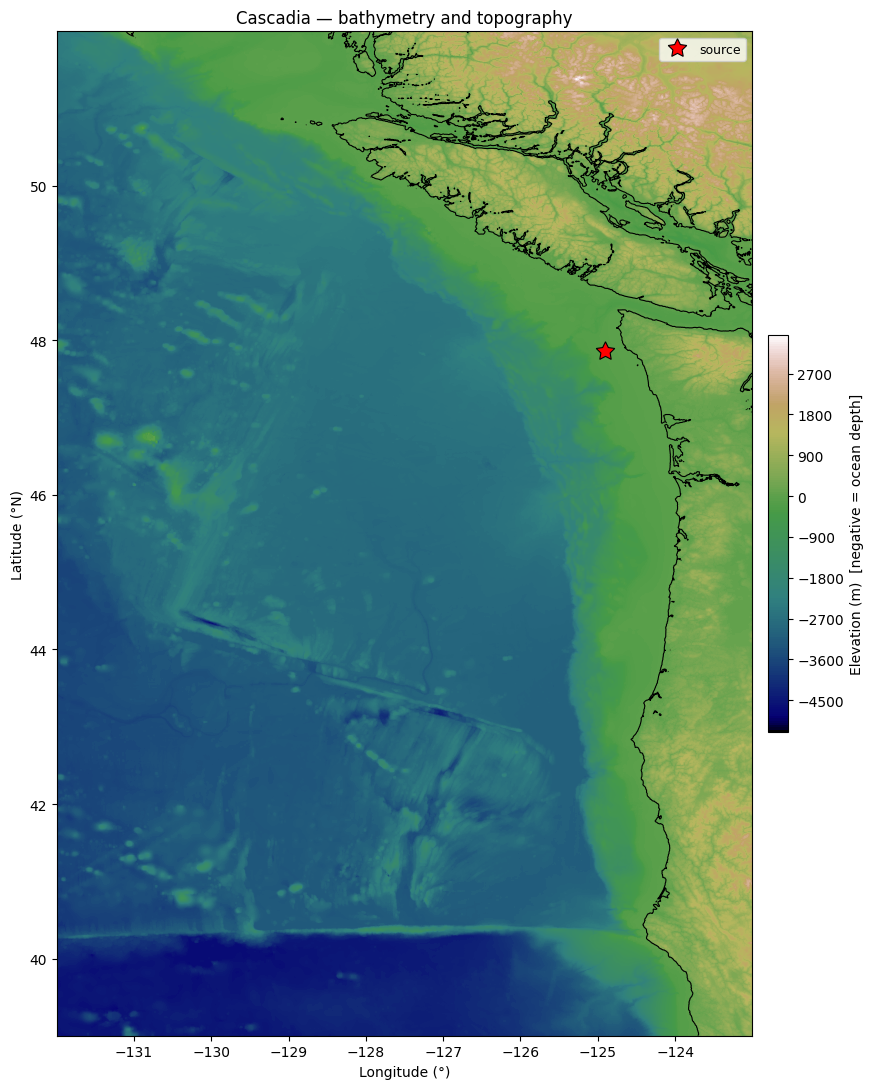

In [75]:
SOURCE_LON = -124.91
SOURCE_LAT =   47.86

vmin = float(np.nanmin(depth_grid))
vmax = float(np.nanmax(depth_grid))
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=max(vmax, 1))

fig, ax = plt.subplots(figsize=(9, 11))

cf = ax.contourf(lon_full, lat_full, depth_grid,
                 levels=200, cmap='gist_earth', norm=norm)

# Coastline at sea level
ax.contour(lon_full, lat_full, depth_grid,
           levels=[0], colors='k', linewidths=0.8)

# Source
ax.plot(SOURCE_LON, SOURCE_LAT,
        marker=(5, 1), markersize=14,
        markerfacecolor='red', markeredgecolor='k', markeredgewidth=0.8,
        linestyle='none', zorder=6, label='source')

ax.set_xlabel('Longitude (\u00b0)')
ax.set_ylabel('Latitude (\u00b0N)')
ax.set_title('Cascadia \u2014 bathymetry and topography')
ax.set_aspect('equal')
ax.legend(fontsize=9)

cbar = fig.colorbar(cf, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label('Elevation (m)  [negative = ocean depth]')
plt.tight_layout()
plt.show()

## Tsunami ray tracing

Fan 360 rays at 1° azimuth spacing from the source and integrate for 3 hours.

In [76]:
DT           =    60.0 # in seconds
MAX_TIME     = 4 * 3600.0 # in seconds
AZIMUTHS_DEG = np.arange(0, 360, 0.2, dtype=float)

print(f'Source  : {SOURCE_LON}\u00b0E, {SOURCE_LAT}\u00b0N')
print(f'Tracing {len(AZIMUTHS_DEG)} rays  '
      f'(dt={DT:.0f} s, max {MAX_TIME/3600:.0f} h) \u2026', end='', flush=True)

# This single line does all the work
# lat_arr = lat_arr[::-1]  # flip lat axis to match depth_grid

ray_lon, ray_lat, _ = tt.trace_rays(
    lon_arr, lat_arr, depth_tracing,
    DT, MAX_TIME,
    SOURCE_LON, SOURCE_LAT,
    AZIMUTHS_DEG,
)

n_done = int(np.sum(~np.isnan(ray_lon[:, -1])))
print(f'  done.  {n_done}/{len(AZIMUTHS_DEG)} rays reached max_time.')

Source  : -124.91°E, 47.86°N
Tracing 1800 rays  (dt=60 s, max 4 h) …  done.  1/1800 rays reached max_time.


In [77]:
print(lon_arr)

[-131.99583333 -131.9875     -131.97916667 ... -123.02083333 -123.0125
 -123.00416667]


## Travel time map

Each ray position is tagged with its elapsed time.  `griddata` interpolates
this point cloud onto the bathymetry grid to produce a smooth
first-arrival travel time surface.

In [78]:
# Tag every non-NaN ray position with its elapsed time
n_steps    = ray_lon.shape[1]
step_times = np.arange(n_steps) * DT
times_2d   = np.broadcast_to(step_times[np.newaxis, :], ray_lon.shape).copy()

valid    = ~np.isnan(ray_lon)
pts_lon  = ray_lon[valid]
pts_lat  = ray_lat[valid]
pts_time = times_2d[valid] / 3600.0   # hours

LON_P, LAT_P = np.meshgrid(lon_full, lat_full)
print(f'Interpolating {valid.sum():,} ray points \u2026', end='', flush=True)
travel_time = griddata(
    (pts_lon, pts_lat), pts_time,
    (LON_P, LAT_P), method='linear',
)
print(' done.')

# Mask land — travel time is only meaningful over water
travel_time[depth_grid >= 0] = np.nan



Interpolating 83,685 ray points … done.


## Let's make a map of all the rays

/var/folders/5x/5xtm6r7126g41vdgwb462xp40000gn/T/ipykernel_11882/751770602.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9)
/var/folders/5x/5xtm6r7126g41vdgwb462xp40000gn/T/ipykernel_11882/751770602.py:25: UserWarning: Adding colorbar to a different Figure <Figure size 900x1100 with 2 Axes> than <Figure size 900x1100 with 2 Axes> which fig.colorbar is called on.
  cbar = fig.colorbar(cf, ax=ax, fraction=0.025, pad=0.02)


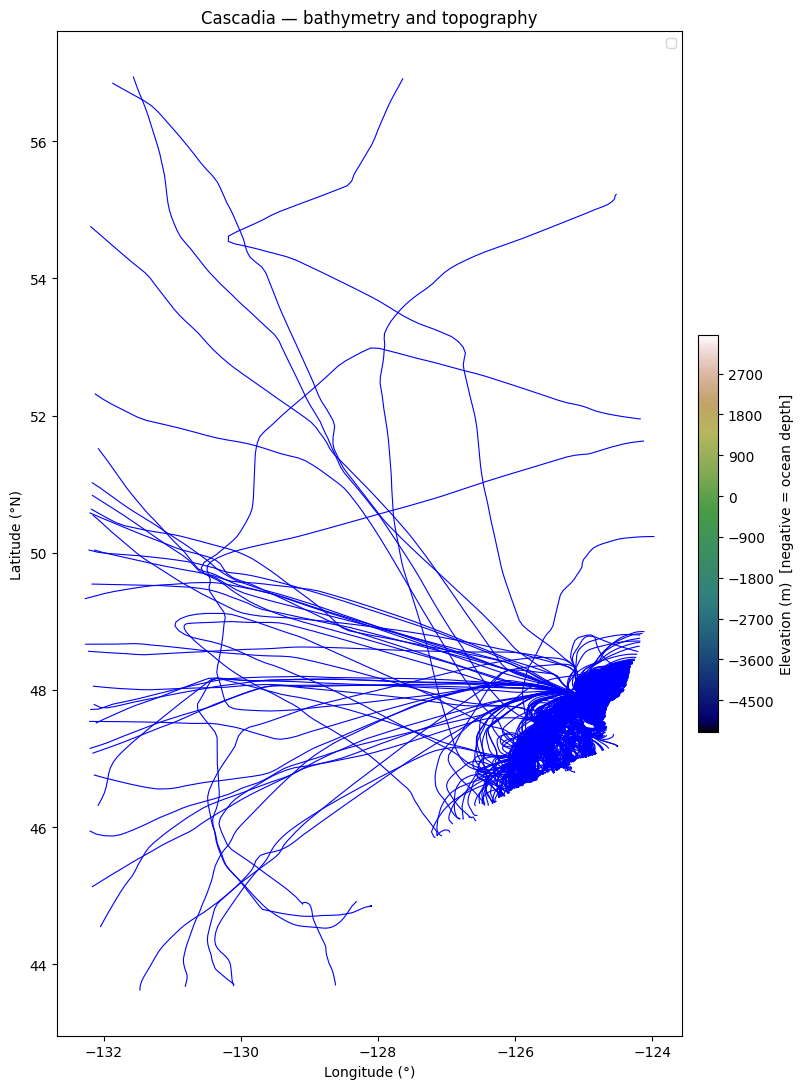

In [79]:
fig, ax = plt.subplots(figsize=(9, 11))

# cf = ax.contourf(lon_full, lat_full, depth_grid,
#                  levels=200, cmap='gist_earth', norm=norm)

# # Coastline at sea level
# ax.contour(lon_full, lat_full, depth_grid,
#            levels=[0], colors='k', linewidths=0.8)

# # Source
# ax.plot(SOURCE_LON, SOURCE_LAT,
#         marker=(5, 1), markersize=14,
#         markerfacecolor='red', markeredgecolor='k', markeredgewidth=0.8,
#         linestyle='none', zorder=6, label='source')

for i in range(ray_lon.shape[0]):
    ax.plot(ray_lon[i], ray_lat[i], color='blue',linewidth=0.8)

ax.set_xlabel('Longitude (\u00b0)')
ax.set_ylabel('Latitude (\u00b0N)')
ax.set_title('Cascadia \u2014 bathymetry and topography')
ax.set_aspect('equal')
ax.legend(fontsize=9)

cbar = fig.colorbar(cf, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label('Elevation (m)  [negative = ocean depth]')
plt.tight_layout()
plt.show()

In [88]:
i,j=np.where(~np.isnan(ray_lat))
ray_lat[i,j].max()

np.float64(56.93539480849643)

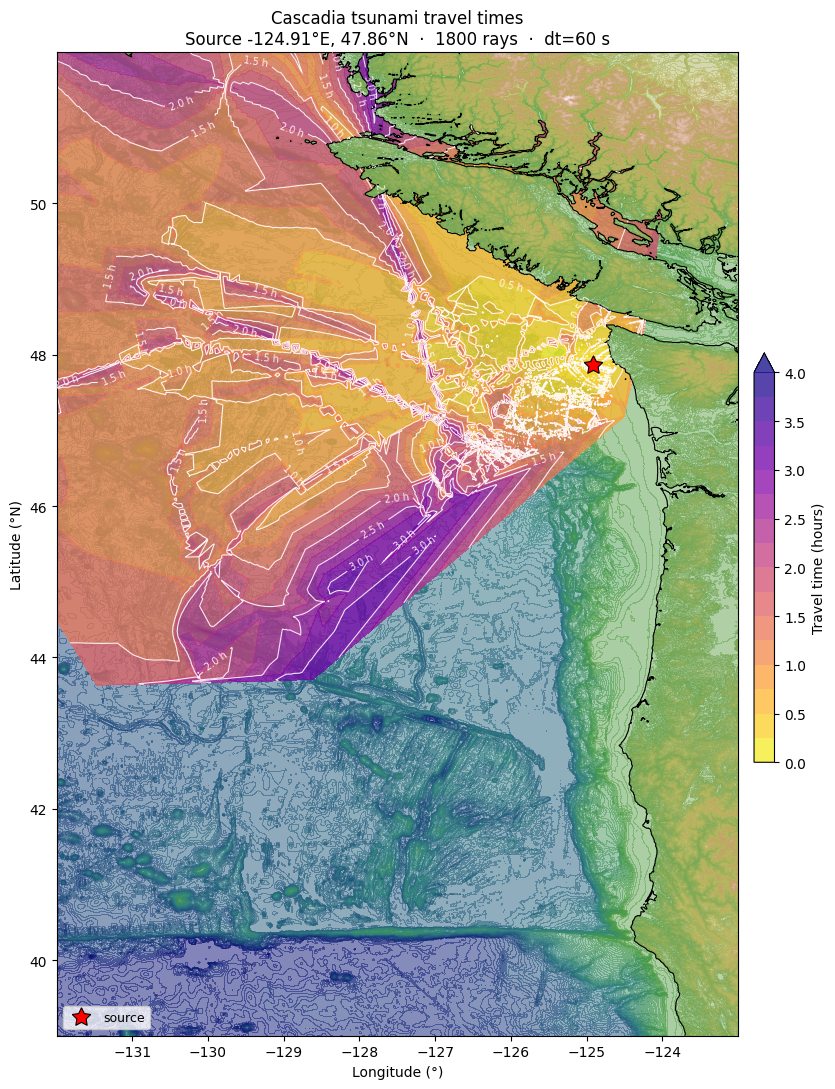

In [80]:
# ── figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 11))

# Muted bathymetry background
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=max(vmax, 1))
ax.contourf(lon_full, lat_full, depth_grid,
            levels=200, cmap='gist_earth', norm=norm, alpha=0.5)
ax.contour(lon_full, lat_full, depth_grid,
           levels=[0], colors='k', linewidths=0.8)

# Travel time — filled contours
tt_max = MAX_TIME / 3600
cf = ax.contourf(lon_full, lat_full, travel_time,
                 levels=np.arange(0, tt_max + 0.25, 0.25),
                 cmap='plasma_r', alpha=0.75, extend='max')

# Isochrone lines every 30 minutes
cs = ax.contour(lon_full, lat_full, travel_time,
                levels=np.arange(0.5, tt_max + 0.5, 0.5),
                colors='white', linewidths=0.8, alpha=0.9)
ax.clabel(cs, fmt='%.1f h', fontsize=7, inline=True)

# Source
ax.plot(SOURCE_LON, SOURCE_LAT,
        marker=(5, 1), markersize=14,
        markerfacecolor='red', markeredgecolor='k', markeredgewidth=0.8,
        linestyle='none', zorder=6, label='source')

ax.set_xlabel('Longitude (\u00b0)')
ax.set_ylabel('Latitude (\u00b0N)')
ax.set_title(
    f'Cascadia tsunami travel times\n'
    f'Source {SOURCE_LON}\u00b0E, {SOURCE_LAT}\u00b0N  \u00b7  '
    f'{len(AZIMUTHS_DEG)} rays  \u00b7  dt={DT:.0f} s'
)
ax.set_aspect('equal')
ax.legend(fontsize=9, loc='lower left')

cbar = fig.colorbar(cf, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label('Travel time (hours)')
plt.tight_layout()
plt.show()